# Relatório da Análise Exploratória de Dados
**Universidade Estadual de Montes Claros**  
**Especialização em Ciência de Dados**  
**Disciplina:** Projeto Integrado em Ciência de Dados  
**Docente:** Dra. Luciana Balieiro Cosme  
**Alunos:**
*  Luan Silva Gomes
*  Mateus Nobre Silva Almeida
*  Paulo Matheus Mendes  

**Projeto:** Predizer o desempenho em Língua Portuguesa e Matemática, do 5º e 9º ano do Ensino Fundamental, das escolas Estaduais e Municipais do estado de Minas Gerais, utilizando a série histórica de 2015-2025 disponível no Portal das Avaliações Educacionais de Minas Gerais, para que Instituições e pessoas interessadas possam tomar medidas e criar políticas com maior eficiência a fim de melhorar esses indicadores.

## Importação de Dependência e Configurações Básicas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Configurações de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Contexto dos Dados
* **Fonte:** Portal das Avaliações Educacionais de Minas Gerais (SIMAVE)
* **Link:** Arquivos das Redes Estadual e Municipal presentes na seção Descritores no Portal das Avaliações do Estado de MG [https://avaliacoes.educacao.mg.gov.br/dados-abertos](https://avaliacoes.educacao.mg.gov.br/dados-abertos)
* **Data de acesso:** 05/06/2026
* **Período avaliado:** 2015 a 2025
* **Variável Alvo (Target):** `% acerto` (transformada em `acerto`)

**Procedimento de obtenção dos dados:**
* Ao acessar a página supracitada, os dados foram baixados utilizando os links de cada ano das Redes Estadual e Municipal presentes na seção Descritores
* Cada link direcionava para uma planilha `.xlsx` no Planilhas (Google Drive) e cada planilha foi transformada no formato `.csv` utilizando a função Arquivo > Baixar > Valores separados por vírgula (.csv) disponível na aplicação Planilhas do Google
* Após o download, os arquivos `.csv` foram renomeados para seguir o padrão `DESCRITORES-<ANO>-ESCOLA-REDE-<MUNICIPAL|ESTADUAL>.csv`

**Observações Sobre Disponibilidade dos Dados:**
- Ainda que disponíveis na página, não foi possível acessar o link das seguintes planilhas da Rede Estadual referentes aos anos de 2017 e 2018 e do ano de 2017 da Rede Municipal
- Além disso, os anos de 2020 e 2025 não possuem dados disponíveis na página

Abaixo o código para carregar os dados, avaliar o tamanho e verificar as variáveis disponíveis.

In [8]:
import pandas as pd
import glob

# Carregando os dados do diretório de trabalho
arquivos = glob.glob('DESCRITORES-*-ESCOLA-REDE-*.csv')
lista_dfs = []

# Mapa de colunas para concatenar colunas com nomes divergentes de anos diferentes
mapa_colunas = {
    'descritores_nome': 'descritor_nome',
    'descritores_descricao': 'descritor_descricao',
    '%.acerto': 'acerto',
    '% acerto': 'acerto', # Renomeia a coluna original sem o símbolo
    'cd_etapa': 'codigo_etapa',
    'cd_escola': 'codigo_escola'
}

for arquivo in arquivos:
    try:
        df_temp = pd.read_csv(arquivo, skiprows=3)
        df_temp = df_temp.rename(columns=mapa_colunas)
        lista_dfs.append(df_temp)
    except Exception as e:
        print(f"Erro ao ler o arquivo {arquivo}: {e}")

if lista_dfs:
    df = pd.concat(lista_dfs, ignore_index=True)

    # 1. Filtro: 5º e 9º ano do Ensino Fundamental
    if 'etapa' in df.columns:
        df['etapa'] = df['etapa'].astype(str).str.strip().str.upper()
        etapas_interesse = ['5º ANO EF', '9º ANO EF']
        df = df[df['etapa'].isin(etapas_interesse)]

    # 2. Limpeza da coluna 'acerto': removendo o símbolo de '%' dos valores (caso exista) e convertendo para número
    if 'acerto' in df.columns:
        # Transforma em string, remove o '%' e converte para numérico (erros viram NaN)
        df['acerto'] = df['acerto'].astype(str).str.replace('%', '', regex=False)
        df['acerto'] = pd.to_numeric(df['acerto'], errors='coerce')

    print(f"\nNúmero total de registros (5º e 9º ano): {df.shape[0]}")
    print(f"Número de variáveis (colunas): {df.shape[1]}\n")
    display(df.head())
else:
    print("Nenhum arquivo encontrado.")


Número total de registros (5º e 9º ano): 2853297
Número de variáveis (colunas): 15



,tipo,codigo_regional,regional,codigo_municipio,municipio,codigo_escola,escola,edicao,rede,codigo_etapa,etapa,disciplina,descritor_nome,descritor_descricao,acerto
36,ESCOLA,1.0,METROPOLITANA B,3106705.0,BETIM,31007773.0,EM FREI ROGATO,2019.0,MUNICIPAL,5.0,5º ANO EF,LINGUA PORTUGUESA,D01,IDENTIFICAR O TEMA OU O SENTIDO GLOBAL DE UM T...,47.0
37,ESCOLA,1.0,METROPOLITANA B,3106705.0,BETIM,31007773.0,EM FREI ROGATO,2019.0,MUNICIPAL,5.0,5º ANO EF,LINGUA PORTUGUESA,D02,LOCALIZAR INFORMACOES EXPLICITAS EM UM TEXTO,66.0
38,ESCOLA,1.0,METROPOLITANA B,3106705.0,BETIM,31007773.0,EM FREI ROGATO,2019.0,MUNICIPAL,5.0,5º ANO EF,LINGUA PORTUGUESA,D03,INFERIR INFORMACOES EM UM TEXTO,57.0
39,ESCOLA,1.0,METROPOLITANA B,3106705.0,BETIM,31007773.0,EM FREI ROGATO,2019.0,MUNICIPAL,5.0,5º ANO EF,LINGUA PORTUGUESA,D04,INFERIR O SENTIDO DE UMA PALAVRA OU EXPRESSAO ...,51.0
40,ESCOLA,1.0,METROPOLITANA B,3106705.0,BETIM,31007773.0,EM FREI ROGATO,2019.0,MUNICIPAL,5.0,5º ANO EF,LINGUA PORTUGUESA,D05,DISTINGUIR UM FATO DE UMA OPINIAO EM UM TEXTO,34.0


## 2. Qualidade dos Dados
Para garantir a qualidade da análise, criamos uma tabela de dados ausentes com a respectiva proporção em relação ao todo. Essa tabela ajuda na tomada de decisão do que fazer com as features afetadas.
Também verificamos registros duplicados antes e depois de removê-los.

In [9]:
# Análise de Valores Ausentes
ausentes = df.isnull().sum()
taxa_ausentes = (df.isnull().mean() * 100).round(2)

df_qualidade = pd.DataFrame({'Valores Ausentes': ausentes, 'Taxa (%)': taxa_ausentes})

# Sugestão de Decisão baseada em uma heurística comum de ciência de dados
df_qualidade['Decisão Sugerida'] = np.where(
    df_qualidade['Taxa (%)'] == 0, 'Manter',
    np.where(df_qualidade['Taxa (%)'] < 5, 'Remover Linha ou Imputar',
    np.where(df_qualidade['Taxa (%)'] < 30, 'Imputar (Média/Mediana/Moda)', 'Avaliar Remoção da Coluna'))
)

print("Tabela de Qualidade e Ausentes por Coluna:")
display(df_qualidade.sort_values(by='Taxa (%)', ascending=False))

# Análise de Duplicatas
duplicatas_antes = df.duplicated().sum()
print(f"\nTotal de registros duplicados antes da limpeza: {duplicatas_antes}")

if duplicatas_antes > 0:
    df = df.drop_duplicates()
    duplicatas_depois = df.duplicated().sum()
    print(f"Total de registros duplicados depois da limpeza: {duplicatas_depois}")
else:
    print("Nenhuma ação de limpeza de duplicatas necessária.")

Tabela de Qualidade e Ausentes por Coluna:


,Valores Ausentes,Taxa (%),Decisão Sugerida
codigo_etapa,502827,17.62,Imputar (Média/Mediana/Moda)
acerto,470219,16.48,Imputar (Média/Mediana/Moda)
tipo,0,0.00,Manter
codigo_municipio,0,0.00,Manter
municipio,0,0.00,Manter
codigo_regional,0,0.00,Manter
regional,0,0.00,Manter
escola,0,0.00,Manter
codigo_escola,0,0.00,Manter
rede,0,0.00,Manter



Total de registros duplicados antes da limpeza: 0
Nenhuma ação de limpeza de duplicatas necessária.


## 3. Distribuições
Abaixo investigamos o comportamento da variável alvo e das variáveis chaves.

Note que como a variável `% acerto` é numérica e contínua, o problema é estruturado tipicamente como Regressão. Logo, não utilizamos o conceito de "classes desbalanceadas" como em classificação, mas sim analisamos a assimetria (skewness) e o formato da distribuição (histograma) para entender se a maior parte das notas está concentrada em valores baixos, altos, ou distribuída normalmente.

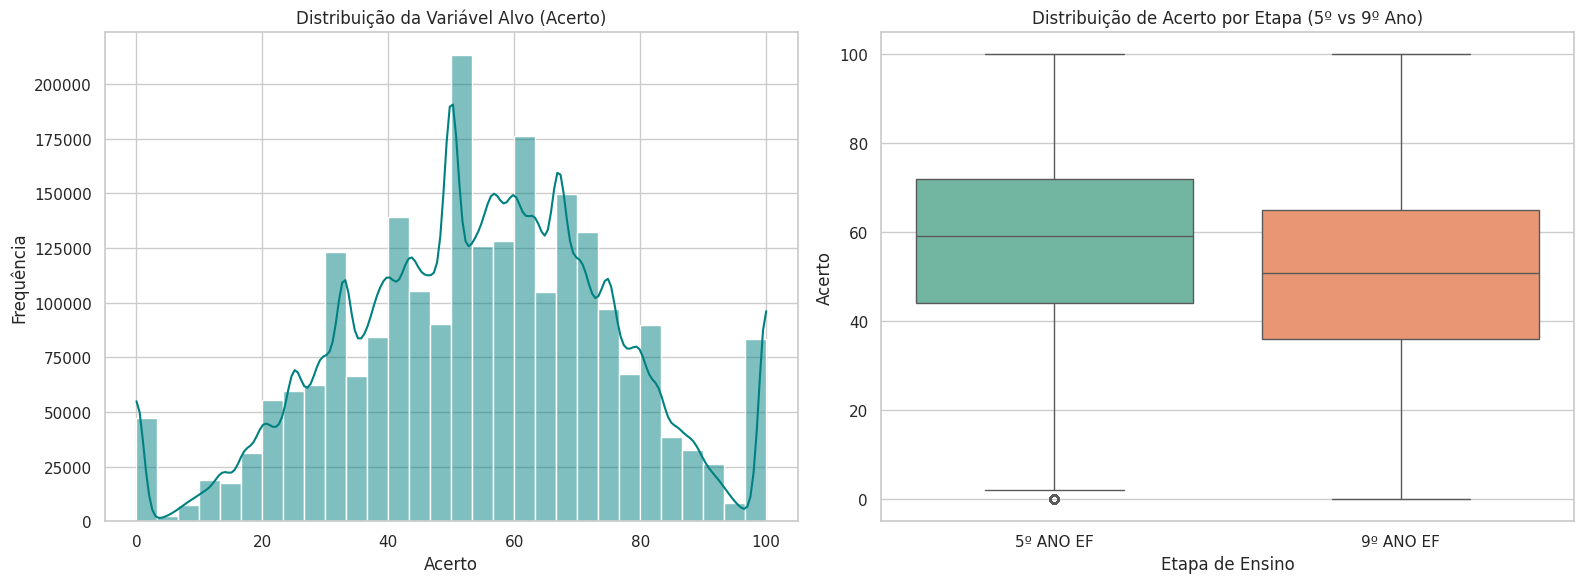


Taxa de Assimetria (Skewness) do target: -0.14
A distribuição apresenta assimetria fraca ou moderada.


In [11]:
# Conversão da variável alvo para numérico
df['acerto'] = pd.to_numeric(df['acerto'], errors='coerce')

# Removendo instâncias que não possuem o target após a conversão
df = df.dropna(subset=['acerto'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['acerto'], bins=30, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribuição da Variável Alvo (Acerto)')
axes[0].set_xlabel('Acerto')
axes[0].set_ylabel('Frequência')
sns.boxplot(data=df, x='etapa', y='acerto', palette='Set2', ax=axes[1])
axes[1].set_title('Distribuição de Acerto por Etapa (5º vs 9º Ano)')
axes[1].set_xlabel('Etapa de Ensino')
axes[1].set_ylabel('Acerto')
plt.tight_layout()
plt.show()

# Calculando Assimetria (Skewness)
assimetria = df['acerto'].skew()
print(f"\nTaxa de Assimetria (Skewness) do target: {assimetria:.2f}")
if abs(assimetria) > 1:
    print("O alvo possui forte assimetria. Considere avaliar transformações para normalidade, se exigido pelo modelo de ML.")
else:
    print("A distribuição apresenta assimetria fraca ou moderada.")

## 4. Relações
A matriz de correlação é plotada com os atributos numéricos. Para enriquecer a análise (uma vez que os dados vêm majoritariamente como códigos ou strings), vamos transformar a disciplina em uma _flag_ e calcular as correlações mais fortes com a nota final.

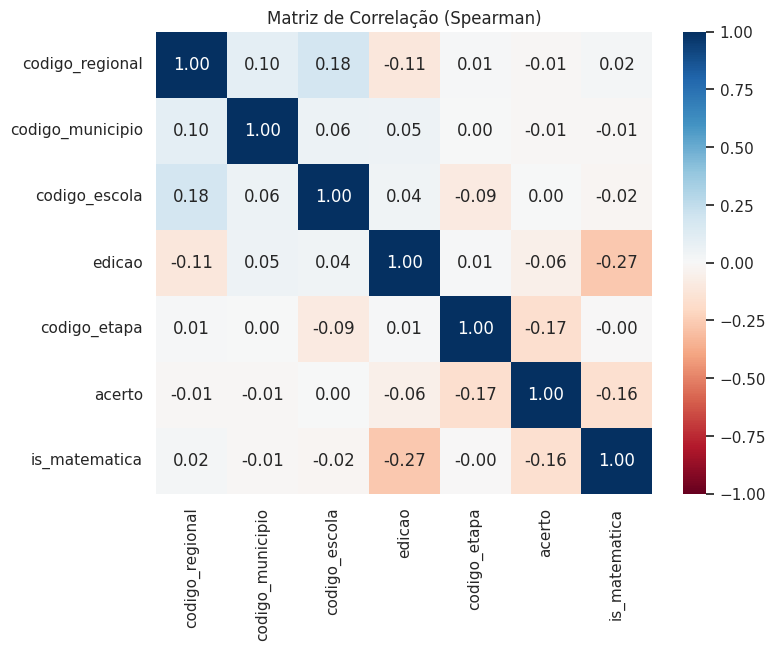


Top Correlações com a Variável Alvo (acerto):


,acerto
codigo_escola,0.003743
codigo_regional,-0.010288
codigo_municipio,-0.013309
edicao,-0.058861
is_matematica,-0.163551
codigo_etapa,-0.168412


In [14]:
# Selecionando apenas features com potencial analítico/numérico do arquivo 'edicao' representa o ano
cols_corr = ['codigo_regional', 'codigo_municipio', 'codigo_escola', 'edicao', 'codigo_etapa', 'acerto']
df_corr = df[cols_corr].copy()

# Feature Engineering básica para extrair mais correlações
df_corr['is_matematica'] = df['disciplina'].str.contains('MATEMATICA', case=False, na=False).astype(int)

# Matriz de Correlação com Spearman que lida variáveis ordinais como ano (edicao)
matriz = df_corr.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação (Spearman)')
plt.show()

print("\nTop Correlações com a Variável Alvo (acerto):")
top_corrs = matriz['acerto'].drop('acerto').sort_values(ascending=False)
display(top_corrs)

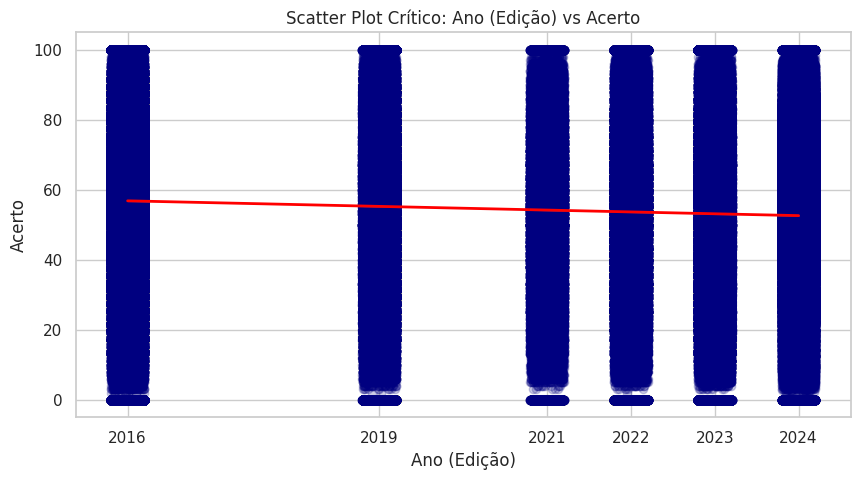

In [15]:
# Scatter Plot
# Analisando a relação da Edição (Ano de aplicação) vs Acerto (para ver evolução temporal básica)
plt.figure(figsize=(10, 5))
sns.regplot(data=df_corr, x='edicao', y='acerto', scatter_kws={'alpha':0.2, 'color': 'navy'},
            line_kws={'color':'red', 'lw':2}, x_jitter=0.2)
plt.title('Scatter Plot Crítico: Ano (Edição) vs Acerto')
plt.xlabel('Ano (Edição)')
plt.ylabel('Acerto')
plt.xticks(sorted(df_corr['edicao'].dropna().unique()))
plt.show()